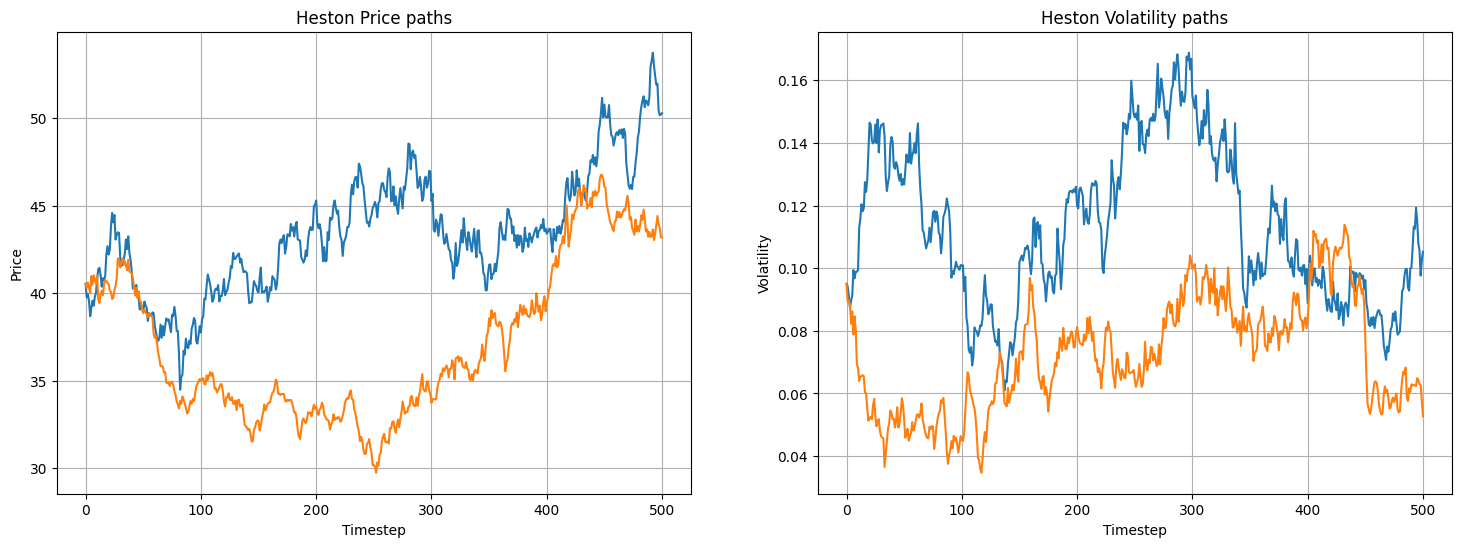

In [3]:
import numpy as np 
#Lets define a few terms for the heston model 

kappa_t=5 #speed of mean reversion 
theta_v=0.1
sigma_v=0.35 #Rate of change of vol

rho_=0.25

S0=40.53
r=0.05
per_year_steps=500 #per year steps 
T=1 #Years 
steps_=int(per_year_steps*T)
v0= 0.095
simulations_=100 # number of simulations 

np.random.seed(42)

corr_matrix=np.array([[1.0, rho_],[rho_, 1.0]])
cholesky_matrix=np.linalg.cholesky(corr_matrix)


def generate_vol(kappa_t,theta_v,sigma_v,v0,simulations_,T,steps_,random_numbers_):
    dt=T/steps_
    V= np.zeros((steps_+1,simulations_))
    V[0]=v0
    for i in range(1,steps_+1):
        random_correlated_matrix=np.dot(cholesky_matrix,random_numbers_[:,i])
        V[i]=np.maximum(0,V[i-1]+kappa_t*(theta_v-V[i-1])*dt+sigma_v*np.sqrt(V[i-1])*random_correlated_matrix[1]*np.sqrt(dt))
    return V

def generate_spot(S0,V,r,simulations_,T,steps_,random_numbers_):
    dt=T/steps_
    S=np.zeros((steps_+1,simulations_))
    S[0]=S0
    for i in range(1,steps_+1):
        random_correlated_matrix=np.dot(cholesky_matrix,random_numbers_[:,i])
        S[i]=S[i-1]*np.exp((r-0.5*V[i-1])*dt+np.sqrt(V[i-1])*random_correlated_matrix[0]*np.sqrt(dt))
    return S

def random_number_generator(steps_,simulations_):
   
    return (np.random.standard_normal((2,steps_+1,simulations_)))
random_numbers_=random_number_generator(steps_,simulations_)

V=generate_vol(kappa_t,theta_v,sigma_v,v0,simulations_,T,steps_,random_numbers_)
S=generate_spot(S0,V,r,simulations_,T,steps_,random_numbers_)
import matplotlib.pyplot as plt
def plot_paths(n):
    fig = plt.figure(figsize=(18, 6))
    ax1 = fig.add_subplot(121)
    ax2 = fig.add_subplot(122)

    ax1.plot(range(len(S)), S[:, :n])
    ax1.grid()
    ax1.set_title("Heston Price paths")
    ax1.set_ylabel("Price")
    ax1.set_xlabel("Timestep")

    ax2.plot(range(len(V)), V[:, :n])
    ax2.grid()
    ax2.set_title("Heston Volatility paths")
    ax2.set_ylabel("Volatility")
    ax2.set_xlabel("Timestep")


plot_paths(2)

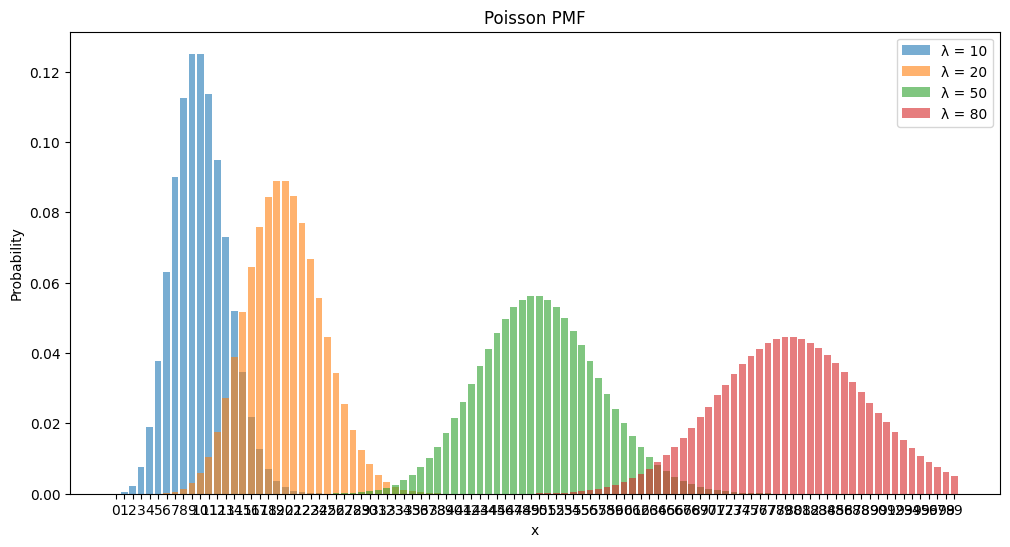

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

x = np.arange(0, 100)
lambdas = [10,20,50,80]

plt.figure(figsize=(12, 6))

for lam in lambdas:
    probs = poisson.pmf(x, lam)
    plt.bar(x, probs, alpha=0.6, label=f'λ = {lam}')

plt.title("Poisson PMF")
plt.xlabel("x")
plt.ylabel("Probability")
plt.xticks(x)
plt.legend()
plt.show()

In [11]:
print(f"Prob when mean is 40 and expected is 40 {poisson.pmf(40, 40)} , while mean is 40 and expected is 2 is {poisson.pmf(2,40)}")

Prob when mean is 40 and expected is 40 0.06294703942359213 , while mean is 40 and expected is 2 is 3.3986834042332738e-15
